In [1]:
from moro import *
from sympy import atan2,sqrt,acos,asin,deg,rad

In [18]:
d1,a2,d4,d6 = 330,320,300,80
R6DOF = Robot((0,pi/2,d1,q1), (a2,0,0,q2), (0,pi/2,0,q3), (0,-pi/2,d4,q4), (0,pi/2,0,q5), (0,0,d6,q6))

In [11]:
T = R6DOF.T

50.1944289077348
-55.6623085467629
191.232553599180
180.000000000000
135.570245052417
-129.805571092265


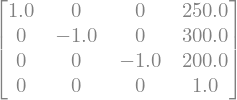

In [19]:
# IK -> Codo abajo
H = Matrix([[1,0,0,250], [0,-1,0,300], [0,0,-1,200], [0,0,0,1]])
xm,ym,zm = H[:3,3] - d6*H[:3,2]
T1 = atan2(ym,xm)
a = sqrt(xm**2 + ym**2)
b = zm - d1
alpha = atan2(b,a)
r = sqrt(a**2 + b**2)
beta = acos((a2**2 + r**2 - d4**2)/(2*a2*r))
T2 = alpha - beta
T3 = acos((r**2 - a2**2 - d4**2)/(2*a2*d4)) + pi/2


R3_0 = R6DOF.R_i0(3).subs({q1:T1,q2:T2,q3:T3}).evalf()
R6_0 = H[:3,:3]
R6_3 = R3_0.inv()*R6_0
T4 = atan2(R6_3[1,2],R6_3[0,2]).evalf(chop=True)
K5 = R6_3[2,2]
T5 = atan2(sqrt(1-K5**2),K5).evalf(chop=True)
T6 = atan2(R6_3[2,1],-R6_3[2,0]).evalf(chop=True)
for _t in [T1,T2,T3,T4,T5,T6]:
    print(deg(_t).evalf())

T.subs({q1:T1,q2:T2,q3:T3,q4:T4,q5:T5,q6:T6}).evalf(6, chop=True)

50.1944289077348
41.0697579447294
-11.2325535991796
180.000000000000
29.8372043455499
-129.805571092265


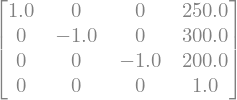

In [24]:
# IK -> Codo arriba
xm,ym,zm = H[:3,3] - d6*H[:3,2]
T1 = atan2(ym,xm)
a = sqrt(xm**2 + ym**2)
b = zm - d1
alpha = atan2(b,a)
r = sqrt(a**2 + b**2)
beta = acos((a2**2 + r**2 - d4**2)/(2*a2*r))
T2 = alpha + beta
T3 = - ( acos((r**2 - a2**2 - d4**2)/(2*a2*d4)) - pi/2 )


R3_0 =  R6DOF.R_i0(3).subs({q1:T1,q2:T2,q3:T3}).evalf()
R6_0 = H[:3,:3]
R6_3 = R3_0.inv()*R6_0
T4 = atan2(R6_3[1,2],R6_3[0,2]).evalf(chop=True)
K5 = R6_3[2,2]
T5 = atan2(sqrt(1-K5**2),K5).evalf(chop=True)
T6 = atan2(R6_3[2,1],-R6_3[2,0]).evalf(chop=True)
for _t in [T1,T2,T3,T4,T5,T6]:
    print(deg(_t).evalf())

T.subs({q1:T1,q2:T2,q3:T3,q4:T4,q5:T5,q6:T6}).evalf(6, chop=True)